# Gradient-Boosted Trees (LightGBM / XGBoost)

**Run this one locally in Anaconda/Jupyter, not in a Claude sandbox.** LightGBM and XGBoost
aren't installable in the environment the earlier notebooks ran in (no network access to
install new packages there) — this notebook needs your local setup, the same one used for the
Student Health Risk project.

```
pip install lightgbm xgboost
```//(skip if already installed — Anaconda often has these already)

**What this tests:** notebooks 3-5 found that a hand-written logistic regression could not be
improved by adding detailed box-score stats (notebook 4) or Massey Ordinal rankings (notebook
5) — both made things slightly worse, most likely because the new features were heavily
correlated with the existing ones, and a linear model doesn't combine correlated features well.
Tree-based models generally handle correlated and missing features more gracefully than linear
models, so this notebook asks: **was the ceiling in notebooks 3-5 about the features, or about
the model?**

**Three models, same 2021-2025 walk-forward folds used throughout this project:**

1. LightGBM, compact features only (3 features) — direct comparison against notebook 3's
   logistic regression on identical features (0.1739 average Brier there)
2. LightGBM, the full feature set (compact + detailed + ordinal, 14 features) — tests whether a
   tree model can make use of the features that hurt the linear model
3. XGBoost, same full feature set — a second tool on the same features, per the original
   project plan's "try XGBoost or LightGBM" step

**A deliberate change from notebooks 3-5: missing values are kept, not dropped.** Ordinal rank
only exists for men's teams and only from 2003 on; detailed stats only exist from 2003
(men's)/2010 (women's). Notebooks 3-5 had to drop every row missing those features, which is
part of why comparisons needed careful control for shrinking training windows. LightGBM and
XGBoost both handle missing values natively (they learn a default split direction for `NaN`
during training), so this notebook feeds in the *full* history for every feature and lets the
model decide what to do with the gaps, rather than throwing rows away.

## 1. Load data (same files as notebooks 3-5)

In [1]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
import xgboost as xgb

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../data")
print(f"lightgbm {lgb.__version__}, xgboost {xgb.__version__}")


lightgbm 4.6.0, xgboost 3.3.0


In [3]:
m_tourney = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
w_tourney = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")
m_seeds = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")
w_seeds = pd.read_csv(DATA_DIR / "WNCAATourneySeeds.csv")
m_reg = pd.read_csv(DATA_DIR / "MRegularSeasonCompactResults.csv")
w_reg = pd.read_csv(DATA_DIR / "WRegularSeasonCompactResults.csv")
m_reg_detail = pd.read_csv(DATA_DIR / "MRegularSeasonDetailedResults.csv")
w_reg_detail = pd.read_csv(DATA_DIR / "WRegularSeasonDetailedResults.csv")
ordinals = pd.read_csv(DATA_DIR / "MMasseyOrdinals.csv")

print(f"men's tourney: {len(m_tourney):,}, women's tourney: {len(w_tourney):,}")


men's tourney: 2,585, women's tourney: 1,717


## 2. Team-season features — compact, detailed, seed, ordinal

Same logic as notebooks 3-5, consolidated into one pass.

In [4]:
def team_season_stats(reg):
    won = reg[["Season", "WTeamID", "WScore", "LScore"]].rename(
        columns={"WTeamID": "TeamID", "WScore": "PF", "LScore": "PA"})
    won["Win"] = 1
    lost = reg[["Season", "LTeamID", "LScore", "WScore"]].rename(
        columns={"LTeamID": "TeamID", "LScore": "PF", "WScore": "PA"})
    lost["Win"] = 0
    games = pd.concat([won, lost], ignore_index=True)
    stats = games.groupby(["Season", "TeamID"]).agg(
        GamesPlayed=("Win", "size"), WinPct=("Win", "mean"),
        AvgPF=("PF", "mean"), AvgPA=("PA", "mean"),
    ).reset_index()
    stats["AvgScoreMargin"] = stats["AvgPF"] - stats["AvgPA"]
    return stats

team_stats = pd.concat([team_season_stats(m_reg), team_season_stats(w_reg)], ignore_index=True)


def team_season_detailed_stats(reg):
    box_cols = ["FGM", "FGA", "FGM3", "FGA3", "FTM", "FTA", "OR", "DR", "Ast", "TO", "Stl", "Blk"]
    won = reg[["Season", "WTeamID", "WScore", "LScore"] + [f"W{c}" for c in box_cols] + [f"L{c}" for c in box_cols]].copy()
    won = won.rename(columns={"WTeamID": "TeamID", "WScore": "PF", "LScore": "PA"})
    won = won.rename(columns={f"W{c}": c for c in box_cols})
    won = won.rename(columns={f"L{c}": f"Opp{c}" for c in box_cols})
    lost = reg[["Season", "LTeamID", "LScore", "WScore"] + [f"L{c}" for c in box_cols] + [f"W{c}" for c in box_cols]].copy()
    lost = lost.rename(columns={"LTeamID": "TeamID", "LScore": "PF", "WScore": "PA"})
    lost = lost.rename(columns={f"L{c}": c for c in box_cols})
    lost = lost.rename(columns={f"W{c}": f"Opp{c}" for c in box_cols})
    games = pd.concat([won, lost], ignore_index=True)
    games["Poss"] = games["FGA"] - games["OR"] + games["TO"] + 0.44 * games["FTA"]
    games["OppPoss"] = games["OppFGA"] - games["OppOR"] + games["OppTO"] + 0.44 * games["OppFTA"]
    games["OffEff_g"] = games["PF"] / games["Poss"] * 100
    games["DefEff_g"] = games["PA"] / games["OppPoss"] * 100
    agg = games.groupby(["Season", "TeamID"]).agg(
        FGM=("FGM", "sum"), FGA=("FGA", "sum"), FGM3=("FGM3", "sum"), FGA3=("FGA3", "sum"),
        FTM=("FTM", "sum"), FTA=("FTA", "sum"), OR=("OR", "mean"), DR=("DR", "mean"),
        Ast=("Ast", "mean"), TO=("TO", "mean"), Stl=("Stl", "mean"), Blk=("Blk", "mean"),
        OffEfficiency=("OffEff_g", "mean"), DefEfficiency=("DefEff_g", "mean"),
    ).reset_index()
    agg["FGPct"] = agg["FGM"] / agg["FGA"]
    agg["FG3Pct"] = agg["FGM3"] / agg["FGA3"]
    agg["FTPct"] = agg["FTM"] / agg["FTA"]
    agg["ReboundRate"] = agg["OR"] + agg["DR"]
    agg["AssistRate"] = agg["Ast"]
    agg["TurnoverRate"] = agg["TO"]
    agg["StealRate"] = agg["Stl"]
    agg["BlockRate"] = agg["Blk"]
    keep = ["Season", "TeamID", "FGPct", "FG3Pct", "FTPct", "ReboundRate", "AssistRate",
            "TurnoverRate", "StealRate", "BlockRate", "OffEfficiency", "DefEfficiency"]
    return agg[keep]

detail_stats = pd.concat(
    [team_season_detailed_stats(m_reg_detail), team_season_detailed_stats(w_reg_detail)], ignore_index=True
)


def seed_num(s):
    return int("".join(ch for ch in s if ch.isdigit()))

m_seeds["SeedNum"] = m_seeds["Seed"].apply(seed_num)
w_seeds["SeedNum"] = w_seeds["Seed"].apply(seed_num)
seeds = pd.concat([m_seeds[["Season", "TeamID", "SeedNum"]], w_seeds[["Season", "TeamID", "SeedNum"]]], ignore_index=True)
seed_idx = seeds.set_index(["Season", "TeamID"])["SeedNum"]

last_day = ordinals.groupby("Season")["RankingDayNum"].transform("max")
final_ordinals = ordinals[ordinals["RankingDayNum"] == last_day]
rank_idx = final_ordinals.groupby(["Season", "TeamID"])["OrdinalRank"].mean()

print(f"compact team-season rows: {len(team_stats):,}")
print(f"detailed team-season rows: {len(detail_stats):,}")
print(f"seed rows: {len(seeds):,}, ranking rows (men's only): {len(rank_idx):,}")


compact team-season rows: 23,604
detailed team-season rows: 14,311
seed rows: 4,506, ranking rows (men's only): 8,345


## 3. Matchup table — full history, features kept as NaN where unavailable (not dropped)

In [5]:
def build_matchups(tourney):
    df = tourney.copy()
    df["Team1"] = df[["WTeamID", "LTeamID"]].min(axis=1)
    df["Team2"] = df[["WTeamID", "LTeamID"]].max(axis=1)
    df["Label"] = (df["WTeamID"] == df["Team1"]).astype(int)
    return df[["Season", "Team1", "Team2", "Label"]]

matchups = pd.concat([build_matchups(m_tourney), build_matchups(w_tourney)], ignore_index=True)

matchups["SeedDiff"] = matchups.apply(
    lambda r: seed_idx.get((r["Season"], r["Team2"]), np.nan) - seed_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)

for team_col, suf in [("Team1", "1"), ("Team2", "2")]:
    joined = matchups.merge(team_stats, left_on=["Season", team_col], right_on=["Season", "TeamID"], how="left")
    matchups[f"WinPct{suf}"] = joined["WinPct"].values
    matchups[f"AvgMargin{suf}"] = joined["AvgScoreMargin"].values
matchups["WinPctDiff"] = matchups["WinPct1"] - matchups["WinPct2"]
matchups["AvgMarginDiff"] = matchups["AvgMargin1"] - matchups["AvgMargin2"]

DETAIL_COLS = ["FGPct", "FG3Pct", "FTPct", "ReboundRate", "AssistRate", "TurnoverRate",
               "StealRate", "BlockRate", "OffEfficiency", "DefEfficiency"]
for team_col, suf in [("Team1", "1"), ("Team2", "2")]:
    joined = matchups.merge(detail_stats, left_on=["Season", team_col], right_on=["Season", "TeamID"], how="left")
    for c in DETAIL_COLS:
        matchups[f"{c}{suf}"] = joined[c].values
for c in DETAIL_COLS:
    matchups[f"{c}Diff"] = matchups[f"{c}1"] - matchups[f"{c}2"]

matchups["Rank1"] = matchups.apply(lambda r: rank_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["Rank2"] = matchups.apply(lambda r: rank_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["OrdinalRankDiff"] = matchups["Rank2"] - matchups["Rank1"]

# only drop rows missing the CORE compact features (should be ~0 - every tourney team has a
# seed and a regular-season record); detailed/ordinal gaps are left as NaN on purpose
before = len(matchups)
matchups = matchups.dropna(subset=["SeedDiff", "WinPctDiff", "AvgMarginDiff"]).reset_index(drop=True)
print(f"matchup rows: {before:,} -> {len(matchups):,} after dropping rows missing core features")

FEATURES_COMPACT = ["SeedDiff", "WinPctDiff", "AvgMarginDiff"]
FEATURES_DETAIL = [f"{c}Diff" for c in DETAIL_COLS]
FEATURES_ALL = FEATURES_COMPACT + FEATURES_DETAIL + ["OrdinalRankDiff"]

print(f"\nmissing-value rate per feature (expected: 0% for compact, >0% for detail/ordinal):")
print((matchups[FEATURES_ALL].isna().mean() * 100).round(1).to_string())


matchup rows: 4,302 -> 4,302 after dropping rows missing core features

missing-value rate per feature (expected: 0% for compact, >0% for detail/ordinal):
SeedDiff              0.0
WinPctDiff            0.0
AvgMarginDiff         0.0
FGPctDiff            44.0
FG3PctDiff           44.0
FTPctDiff            44.0
ReboundRateDiff      44.0
AssistRateDiff       44.0
TurnoverRateDiff     44.0
StealRateDiff        44.0
BlockRateDiff        44.0
OffEfficiencyDiff    44.0
DefEfficiencyDiff    44.0
OrdinalRankDiff      66.3


## 4. Walk-forward comparison: LightGBM (compact) vs. LightGBM (all features) vs. XGBoost (all features)

Deliberately conservative hyperparameters given the small dataset (a few thousand rows) — shallow trees, moderate leaf count, some L2 regularization. Tuning these properly is Optuna's job later in the project plan, not this notebook's.

In [6]:
FOLD_SEASONS = [2021, 2022, 2023, 2024, 2025]

LGB_PARAMS = dict(
    n_estimators=200, num_leaves=15, max_depth=4, learning_rate=0.05,
    min_child_samples=20, reg_lambda=1.0, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=-1,
)
XGB_PARAMS = dict(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    min_child_weight=5, reg_lambda=1.0, subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric="logloss",
)

def brier_score(p, y):
    return float(np.mean((np.asarray(p) - np.asarray(y)) ** 2))

results = []
for fold_season in FOLD_SEASONS:
    train = matchups[matchups["Season"] < fold_season]
    test = matchups[matchups["Season"] == fold_season]
    if len(test) == 0:
        continue

    m1 = lgb.LGBMClassifier(**LGB_PARAMS)
    m1.fit(train[FEATURES_COMPACT], train["Label"])
    p1 = m1.predict_proba(test[FEATURES_COMPACT])[:, 1]

    m2 = lgb.LGBMClassifier(**LGB_PARAMS)
    m2.fit(train[FEATURES_ALL], train["Label"])
    p2 = m2.predict_proba(test[FEATURES_ALL])[:, 1]

    m3 = xgb.XGBClassifier(**XGB_PARAMS)
    m3.fit(train[FEATURES_ALL], train["Label"])
    p3 = m3.predict_proba(test[FEATURES_ALL])[:, 1]

    results.append({
        "FoldSeason": fold_season, "NGames": len(test), "NTrain": len(train),
        "LightGBM (compact)": brier_score(p1, test["Label"]),
        "LightGBM (all features)": brier_score(p2, test["Label"]),
        "XGBoost (all features)": brier_score(p3, test["Label"]),
    })

results_df = pd.DataFrame(results)
model_cols = ["LightGBM (compact)", "LightGBM (all features)", "XGBoost (all features)"]
avg_row = {"FoldSeason": "Average", "NGames": results_df["NGames"].sum(), "NTrain": np.nan}
avg_row.update({c: results_df[c].mean() for c in model_cols})
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)
print(results_df.round(4).to_string(index=False))

print("\nfor reference, notebook 3-5 logistic regression results (hand-written, numpy):")
print("  compact (3 feat), full history:        0.1739")
print("  compact + detailed (13 feat):           0.1759")
print("  compact + ordinal (4 feat, men's only):  0.2037")


FoldSeason  NGames  NTrain  LightGBM (compact)  LightGBM (all features)  XGBoost (all features)
      2021     129  3637.0              0.1906                   0.1863                  0.1911
      2022     134  3766.0              0.1934                   0.1964                  0.2054
      2023     134  3900.0              0.1909                   0.2025                  0.1992
      2024     134  4034.0              0.1681                   0.1676                  0.1664
      2025     134  4168.0              0.1445                   0.1492                  0.1490
   Average     665     NaN              0.1775                   0.1804                  0.1822

for reference, notebook 3-5 logistic regression results (hand-written, numpy):
  compact (3 feat), full history:        0.1739
  compact + detailed (13 feat):           0.1759
  compact + ordinal (4 feat, men's only):  0.2037


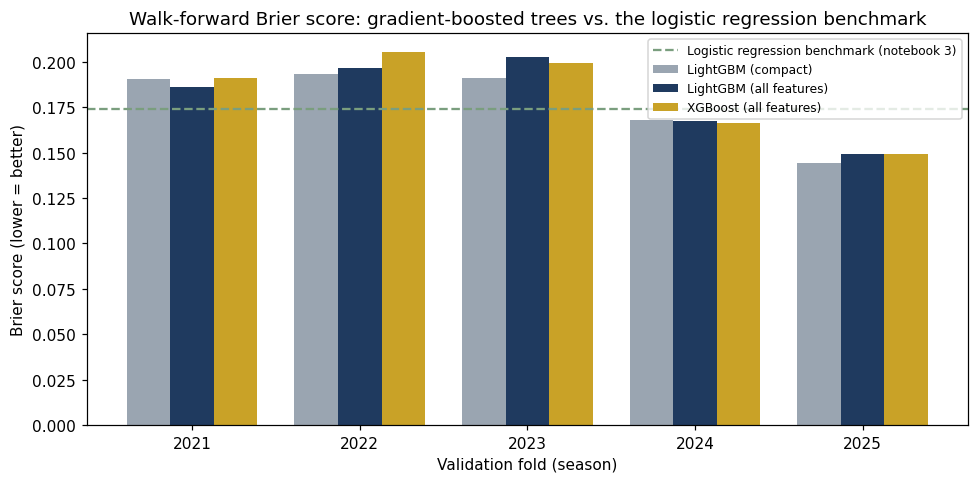

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = results_df[results_df["FoldSeason"] != "Average"]
x = np.arange(len(plot_df))
width = 0.26
colors = ["#9aa5b1", "#1f3a5f", "#c9a227"]
for i, col in enumerate(model_cols):
    ax.bar(x + (i - 1) * width, plot_df[col], width, label=col, color=colors[i])
ax.axhline(0.1739, color="#7a9e7e", linestyle="--", linewidth=1.5, label="Logistic regression benchmark (notebook 3)")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["FoldSeason"])
ax.set_ylabel("Brier score (lower = better)")
ax.set_xlabel("Validation fold (season)")
ax.set_title("Walk-forward Brier score: gradient-boosted trees vs. the logistic regression benchmark")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 5. Feature importance — does the tree model actually use the detailed/ordinal features?

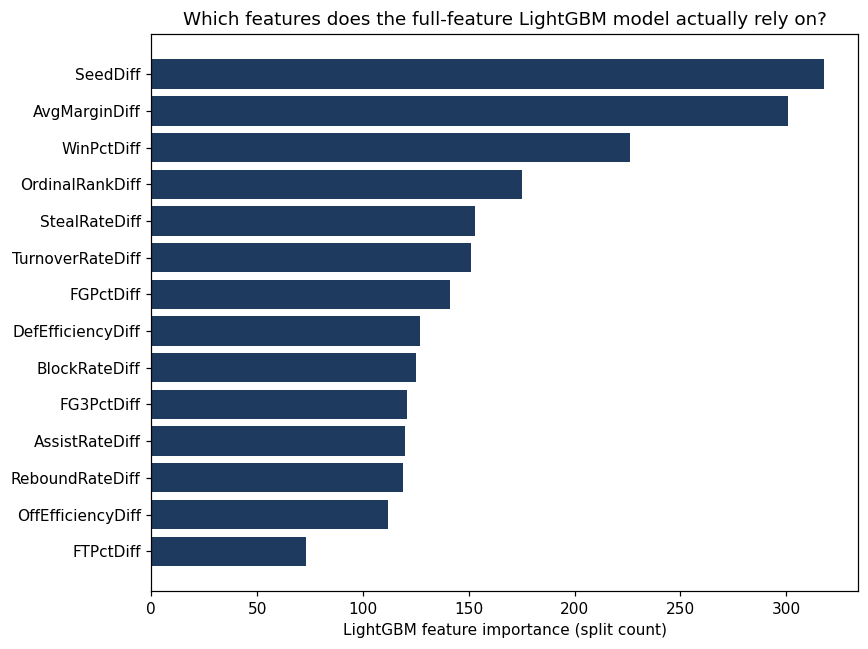

          Feature  Importance
         SeedDiff         318
    AvgMarginDiff         301
       WinPctDiff         226
  OrdinalRankDiff         175
    StealRateDiff         153
 TurnoverRateDiff         151
        FGPctDiff         141
DefEfficiencyDiff         127
    BlockRateDiff         125
       FG3PctDiff         121
   AssistRateDiff         120
  ReboundRateDiff         119
OffEfficiencyDiff         112
        FTPctDiff          73


In [8]:
final_model = lgb.LGBMClassifier(**LGB_PARAMS)
final_model.fit(matchups[FEATURES_ALL], matchups["Label"])

importance = pd.DataFrame({
    "Feature": FEATURES_ALL,
    "Importance": final_model.feature_importances_,
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance["Feature"][::-1], importance["Importance"][::-1], color="#1f3a5f")
ax.set_xlabel("LightGBM feature importance (split count)")
ax.set_title("Which features does the full-feature LightGBM model actually rely on?")
fig.tight_layout()
plt.show()

print(importance.to_string(index=False))


## Conclusion

**Headline: none of the tree-based models beat the plain logistic regression benchmark.**
Average Brier across the 5 folds: LightGBM (compact, 3 features) 0.1775, LightGBM (all 14
features) 0.1804, XGBoost (all 14 features) 0.1822 — all worse than notebook 3's hand-written
logistic regression on the same compact features, which scored 0.1739. The chart makes this
plain: every tree-model bar sits above the logistic-regression reference line in 4 of the 5
folds, with 2021 as the one exception where LightGBM (all features) dipped below it.

**This answers the question this notebook set out to ask: the ceiling in notebooks 3-5 was not
about the model class.** Switching from a linear model to gradient-boosted trees, which handle
correlated and missing features more gracefully in general, did not unlock better performance on
this data. That's a meaningful negative result, not a wasted effort — it rules out "logistic
regression just isn't powerful enough" as the explanation and points elsewhere instead.

**But the feature-importance chart tells a more nuanced story than "more features are useless."**
Unlike notebook 5, where `OrdinalRankDiff`'s logistic regression coefficient shrank to nearly
zero once `SeedDiff` was in the model, LightGBM ranks `OrdinalRankDiff` 4th out of 14 features by
importance — clearly using it. The efficiency and box-score features get real, if smaller, use
too, rather than being ignored. So the tree model *is* extracting more information out of the
correlated features than the linear model could — it just isn't translating into a better overall
score, most likely because a 14-feature tree model has more capacity to overfit a training set of
only ~3,600-4,200 rows than a 3-feature one does, and that overfitting cost cancels out the
benefit of the extra information.

**Most likely explanation, and the natural next test:** these tree models used fixed, deliberately
conservative hyperparameters, not tuned ones. It's entirely possible a properly-tuned LightGBM
(fewer leaves, stronger regularization, or fewer boosting rounds to control overfitting on this
small dataset) would close the gap with — or beat — the logistic regression baseline. That's a
real, promising next step rather than a dead end: Optuna tuning (already in the project plan) is
the right next lever, and it's now motivated by a concrete comparison rather than being tried
speculatively.

**Where this leaves the project after four modeling notebooks (3-6):** the simple 3-feature
logistic regression from notebook 3 is still the best result obtained so far (0.1739 Brier), and
every attempt to improve on it — more features (notebook 4), a different feature (notebook 5), or
a different, generally more powerful model class (this notebook) — has come up short *without
tuning*. That's a consistent, credible signal that this feature set is close to its ceiling for
an untuned model, and the next real lever is hyperparameter tuning rather than another feature or
model-class swap.

**Caveats:** same small-fold-count caution as every notebook in this series (5 folds, ~130-270
games each — genuinely noisy). Hyperparameters were fixed, not tuned, so this is a comparison of
"default-ish tree model" vs. "correctly-specified linear model," not "the best possible version of
each." `OrdinalRankDiff` is missing for the large majority of rows (66.3%) and the detailed stats
for 44% — both libraries handle this internally, but it's still a lot of missingness to learn
around with limited data.

**Next step:** Optuna hyperparameter tuning on the LightGBM (all features) model, since it has
the most room to improve and the current run used untuned defaults. If tuning closes the gap with
the logistic regression benchmark, that becomes the model to carry toward an actual Kaggle
submission; if it doesn't, that's still valuable evidence that ~0.17 Brier is a real, feature-set-
driven ceiling rather than a tuning problem.
